In [1]:
from fem.solver import CahnHilliardSolver
import numpy as np
import matplotlib.pyplot as plt

# Physics
epsilon = 0.01

# Discretization
L = 1

dt = 1e-8
tEnd = 1e-3

# Initial conditions
def c0(x): return np.cos(np.pi/L*x)
# def c0(x): return np.sin(np.pi/(L)*x)


# EXPLICIT SOLVER

## Linear Elements

In [2]:
N = 100
poly_degree = 1
linear = CahnHilliardSolver(epsilon, 
                         number_of_elements=N, L = L, 
                         polynomial_order=poly_degree)
linear.solve(c0, tEnd, dt, time_integrator=0)

100%|██████████| 100000/100000 [31:48<00:00, 52.38it/s] 


## Quadratic Elements

In [3]:
N = 25
poly_degree = 2
quad = CahnHilliardSolver(epsilon, 
                         number_of_elements=N, L = L, 
                         polynomial_order=poly_degree)
quad.solve(c0, tEnd, dt, time_integrator=0)

100%|██████████| 100000/100000 [14:28<00:00, 115.15it/s]


# Plotting

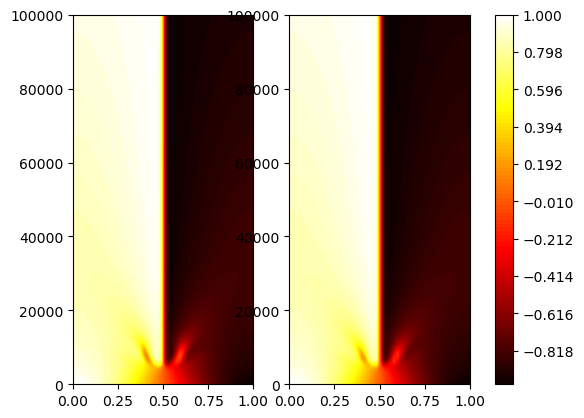

In [4]:
fig, ax = plt.subplots(1,2)
levels = np.linspace(-1, 1, 100)
map = 'hot'

X, Y = np.meshgrid(linear.x, linear.t/dt)
cs1 = ax[0].contourf(X, Y, linear.sol_c, levels = levels, cmap = map)

X, Y = np.meshgrid(quad.x, quad.t/dt)
cs2 = ax[1].contourf(X, Y, quad.sol_c, levels = levels, cmap = map)


cbar = fig.colorbar(cs1, ax=ax, orientation='vertical')
cbar.set_label('')

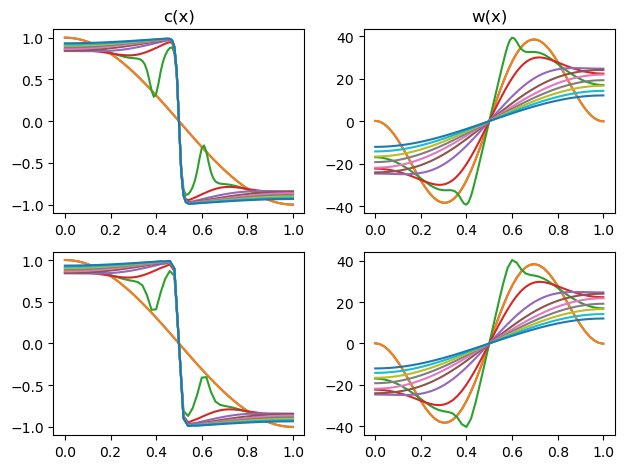

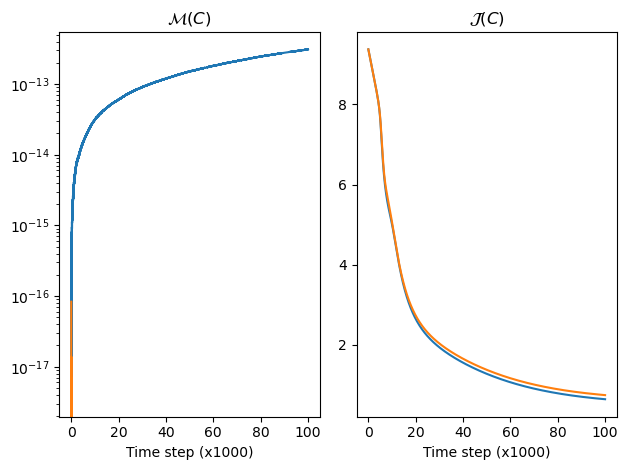

In [7]:
fig1, ax1 = plt.subplots(2,2)
ax1 = ax1.flatten()
ax1[0].plot(linear.x, linear.sol_c[0])
ax1[1].plot(linear.x, linear.sol_w[0])
if len(linear.t) > 1:
    for i in range(1,len(linear.t), max(len(linear.t)//10,1)):
        ax1[0].plot(linear.x, linear.sol_c[i])
        ax1[1].plot(linear.x, linear.sol_w[i])
ax1[2].plot(quad.x, quad.sol_c[0])
ax1[3].plot(quad.x, quad.sol_w[0])
if len(linear.t) > 1:
    for i in range(1,len(quad.t), max(len(quad.t)//10,1)):
        ax1[2].plot(quad.x, quad.sol_c[i])
        ax1[3].plot(quad.x, quad.sol_w[i])
ax1[0].set_title('c(x)')
ax1[1].set_title('w(x)')
fig1.tight_layout()



fig2, ax2 = plt.subplots(1,2)
ax2[0].plot(linear.t/dt/1e3, linear.mass, label = 'Linaer')
ax2[0].plot(quad.t/dt/1e3, quad.mass, label = 'Quadratic')

ax2[0].set_title('$\\mathcal{M}(C)$')
ax2[0].set_yscale('log')

ax2[1].plot(linear.t/dt/1e3, linear.J, label = 'Linaer')
ax2[1].plot(quad.t/dt/1e3, quad.J, label = 'Quadratic')
ax2[1].set_title('$\\mathcal{J}(C)$')
[_.set_xlabel('Time step (x1000)') for _ in ax2]
fig2.tight_layout()